# Experiment 7: Which Single Skill Has the Highest Marginal Salary Value?

**Research question:** If a candidate invests in learning one additional skill, which skill is associated with the largest salary premium in data-science-related job postings?

**Operational definition of marginal value:** For each skill, estimate the salary premium associated with mentioning that skill after controlling for dataset source, role family, seniority, remote status, and the total number of other matched skills in the posting.

**Why this experiment matters:** A raw mean-salary comparison can exaggerate a skill's value if that skill mostly appears in senior or specialized roles. This notebook uses one-skill-at-a-time adjusted regressions to rank skills more fairly.

**Important caution:** This is an observational job-posting analysis. It estimates market association, not the causal personal return from learning a skill.

In [1]:
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from helpers import SKILL_PATTERNS, parse_salary
from job_dataset_union import build_unified_jobs_df

In [2]:
ROLE_BUCKET_PATTERNS = [
    ("data_scientist", r"\b(data scientist|decision scientist|applied scientist|research scientist)\b"),
    ("machine_learning", r"\b(machine learning engineer|ml engineer|ai engineer|artificial intelligence engineer|llm engineer)\b"),
    ("data_engineer", r"\bdata engineer\b"),
    ("analyst_bi", r"\b(data analyst|business intelligence|bi analyst|analytics engineer|analyst)\b"),
    ("statistician", r"\b(statistician|statistical)\b"),
]

ENTRY_PATTERN = r"\b(?:intern|internship|junior|jr\.?|entry[- ]level|graduate|new grad|associate)\b"
SENIOR_PATTERN = r"\b(?:senior|sr\.?|lead|principal|staff|manager|head|director)\b"
MIN_SKILL_SUPPORT = 40
MIN_SALARY_USD = 30_000
MAX_SALARY_USD = 400_000


def assign_role_bucket(title):
    title = str(title).lower()
    for label, pattern in ROLE_BUCKET_PATTERNS:
        if re.search(pattern, title):
            return label
    return "other"


def fit_ols_hc3(y, X):
    # Small self-contained OLS helper with HC3 robust standard errors.
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)

    xtx_inv = np.linalg.pinv(X.T @ X)
    beta = xtx_inv @ (X.T @ y)
    residuals = y - X @ beta
    leverage = np.sum((X @ xtx_inv) * X, axis=1)

    hc3_scale = (residuals / np.clip(1 - leverage, 1e-8, None)) ** 2
    meat = X.T @ (X * hc3_scale[:, None])
    covariance = xtx_inv @ meat @ xtx_inv

    standard_errors = np.sqrt(np.clip(np.diag(covariance), 0, None))
    t_statistics = beta / np.where(standard_errors == 0, np.nan, standard_errors)
    p_values = 2 * stats.norm.sf(np.abs(t_statistics))
    return beta, standard_errors, p_values


def log_beta_to_percent(beta):
    return (np.exp(beta) - 1) * 100

In [3]:
df = build_unified_jobs_df().copy()

df["salary_usd"] = df["salary_range"].apply(parse_salary)
df["title_text"] = df["job_title"].fillna("").astype(str)
df["location_text"] = df["location"].fillna("").astype(str)
df["role_bucket"] = df["title_text"].apply(assign_role_bucket)

analysis_df = df[df["role_bucket"] != "other"].copy()
analysis_df = analysis_df[analysis_df["salary_usd"].between(MIN_SALARY_USD, MAX_SALARY_USD)].copy()
analysis_df = analysis_df[
    analysis_df["job_description_skills"].fillna("").astype(str).str.strip() != ""
].copy()
analysis_df["is_remote"] = analysis_df["location_text"].str.lower().str.contains(r"\bremote\b", regex=True)

entry_mask = analysis_df["title_text"].str.lower().str.contains(ENTRY_PATTERN, regex=True)
senior_mask = analysis_df["title_text"].str.lower().str.contains(SENIOR_PATTERN, regex=True)
analysis_df["seniority_bucket"] = np.select(
    [entry_mask & ~senior_mask, senior_mask & ~entry_mask],
    ["entry_level", "senior_plus"],
    default="mid_level",
)

skill_flags = pd.DataFrame(
    {
        skill: analysis_df["job_description_skills"].fillna("").astype(str).str.contains(pattern, case=False, regex=True)
        for skill, pattern in SKILL_PATTERNS.items()
    },
    index=analysis_df.index,
)

analysis_df["matched_skill_count"] = skill_flags.sum(axis=1)
analysis_df = analysis_df[analysis_df["matched_skill_count"] > 0].copy()
skill_flags = skill_flags.loc[analysis_df.index]
analysis_df["log_salary"] = np.log(analysis_df["salary_usd"])

print(f"Unified rows loaded: {len(df)}")
print(f"Rows after role/salary/skill filters: {len(analysis_df)}")
print(f"Median salary in analysis sample: ${analysis_df['salary_usd'].median():,.0f}")
print()
print("Source breakdown:")
print(analysis_df["source_dataset"].value_counts().to_string())
print()
print("Role-family breakdown:")
print(analysis_df["role_bucket"].value_counts().to_string())
print()
print("Tracked skills meeting minimum support:")
print(skill_flags.sum().sort_values(ascending=False).loc[lambda s: s >= MIN_SKILL_SUPPORT].to_string())

Unified rows loaded: 4444
Rows after role/salary/skill filters: 1390
Median salary in analysis sample: $126,000

Source breakdown:
source_dataset
data_science_job_posts_2025    691
glassdoor_2023                 528
our_own_dataset                171

Role-family breakdown:
role_bucket
data_scientist      1160
data_engineer         82
analyst_bi            76
machine_learning      72

Tracked skills meeting minimum support:
Machine Learning         891
Python                   817
SQL                      585
R                        419
AWS                      258
Statistics               256
Deep Learning            209
Spark                    190
Tableau                  186
Azure                    171
Data Visualization       167
TensorFlow               166
PyTorch                  149
Business Intelligence    128
Scikit-learn             123
Git                      111
Pandas                   105
GCP                      104
ETL                      103
Communication        

## Estimate Marginal Value Skill by Skill

For each skill that appears in at least `MIN_SKILL_SUPPORT` postings, we run a separate regression on `log_salary` with:

- a binary flag for the focal skill
- `matched_skill_count` to hold the overall breadth of skills roughly constant
- controls for `source_dataset`, `role_bucket`, `seniority_bucket`, and remote status

This makes the focal skill coefficient closer to a "what is the added salary premium of this skill, all else equal?" interpretation.

In [4]:
base_design = pd.DataFrame(
    {
        "const": 1.0,
        "is_remote": analysis_df["is_remote"].astype(float),
        "matched_skill_count": analysis_df["matched_skill_count"].astype(float),
    },
    index=analysis_df.index,
)

base_design = pd.concat(
    [
        base_design,
        pd.get_dummies(analysis_df["source_dataset"], prefix="source", drop_first=True, dtype=float),
        pd.get_dummies(analysis_df["role_bucket"], prefix="role", drop_first=True, dtype=float),
        pd.get_dummies(analysis_df["seniority_bucket"], prefix="seniority", drop_first=True, dtype=float),
    ],
    axis=1,
)

median_salary = analysis_df["salary_usd"].median()
results = []

for skill in skill_flags.columns:
    support = int(skill_flags[skill].sum())
    if support < MIN_SKILL_SUPPORT or support > len(analysis_df) - MIN_SKILL_SUPPORT:
        continue

    X = base_design.copy()
    X["has_skill"] = skill_flags[skill].astype(float)

    beta, standard_errors, p_values = fit_ols_hc3(
        analysis_df["log_salary"].to_numpy(),
        X.to_numpy(),
    )

    skill_beta = beta[-1]
    premium_pct = log_beta_to_percent(skill_beta)
    skill_mask = skill_flags[skill]
    mean_with_skill = analysis_df.loc[skill_mask, "salary_usd"].mean()
    mean_without_skill = analysis_df.loc[~skill_mask, "salary_usd"].mean()

    results.append(
        {
            "skill": skill,
            "support": support,
            "share_pct": support / len(analysis_df) * 100,
            "premium_pct": premium_pct,
            "approx_salary_delta_usd": median_salary * (premium_pct / 100),
            "coef_log_salary": skill_beta,
            "std_error": standard_errors[-1],
            "p_value": p_values[-1],
            "mean_with_skill": mean_with_skill,
            "mean_without_skill": mean_without_skill,
            "naive_salary_gap_usd": mean_with_skill - mean_without_skill,
        }
    )

results_df = pd.DataFrame(results).sort_values(
    ["premium_pct", "support"],
    ascending=[False, False],
).reset_index(drop=True)
results_df["significant_5pct"] = results_df["p_value"] < 0.05
results_df["market_value_score"] = results_df["premium_pct"].clip(lower=0) * results_df["share_pct"]

print("Top 15 skills by adjusted salary premium:")
print(
    results_df[
        ["skill", "support", "share_pct", "premium_pct", "approx_salary_delta_usd", "p_value"]
    ].head(15).to_string(index=False)
)

Top 15 skills by adjusted salary premium:
                skill  support  share_pct  premium_pct  approx_salary_delta_usd  p_value
                    R      419  30.143885    14.447083             18203.324741 0.000005
         Optimization       42   3.021583    11.480028             14464.835770 0.005221
                  SQL      585  42.086331    10.224504             12882.875025 0.001354
          A/B Testing       56   4.028777    10.165606             12808.664074 0.017987
                  ETL      103   7.410072     9.711761             12236.818376 0.032588
        Generative AI       51   3.669065     6.308272              7948.422326 0.227969
          Time Series       57   4.100719     5.852360              7373.973050 0.146033
     Machine Learning      891  64.100719     5.287692              6662.491967 0.016179
          Data Mining       68   4.892086     5.263003              6631.383387 0.109060
                Excel       53   3.812950     5.115292              

In [5]:
significant_positive = results_df[
    (results_df["premium_pct"] > 0) & (results_df["significant_5pct"])
].copy()

print("Most valuable single-skill investments by adjusted premium:")
if significant_positive.empty:
    print("No skills have a positive and statistically significant premium at the 5% level.")
else:
    print(
        significant_positive[
            ["skill", "support", "share_pct", "premium_pct", "approx_salary_delta_usd", "p_value"]
        ].head(10).to_string(index=False)
    )

print("\nIf you want to balance premium with market prevalence:")
print(
    results_df[results_df["premium_pct"] > 0]
    .sort_values(["market_value_score", "premium_pct"], ascending=False)[
        ["skill", "support", "share_pct", "premium_pct", "market_value_score"]
    ]
    .head(10)
    .to_string(index=False)
)

print("\nFull ranking table:")
results_df.head(25)

Most valuable single-skill investments by adjusted premium:
           skill  support  share_pct  premium_pct  approx_salary_delta_usd  p_value
               R      419  30.143885    14.447083             18203.324741 0.000005
    Optimization       42   3.021583    11.480028             14464.835770 0.005221
             SQL      585  42.086331    10.224504             12882.875025 0.001354
     A/B Testing       56   4.028777    10.165606             12808.664074 0.017987
             ETL      103   7.410072     9.711761             12236.818376 0.032588
Machine Learning      891  64.100719     5.287692              6662.491967 0.016179

If you want to balance premium with market prevalence:
                skill  support  share_pct  premium_pct  market_value_score
                    R      419  30.143885    14.447083          435.491211
                  SQL      585  42.086331    10.224504          430.311858
     Machine Learning      891  64.100719     5.287692          338.944

,skill,support,share_pct,premium_pct,approx_salary_delta_usd,coef_log_salary,std_error,p_value,mean_with_skill,mean_without_skill,naive_salary_gap_usd,significant_5pct,market_value_score
0,R,419,30.143885,14.447083,18203.324741,0.134942,0.029509,0.000005,146350.977017,125293.636766,21057.340250,True,435.491211
1,Optimization,42,3.021583,11.480028,14464.835770,0.108675,0.038909,0.005221,130003.059048,131692.175215,-1689.116168,True,34.687856
2,SQL,585,42.086331,10.224504,12882.875025,0.097349,0.030380,0.001354,136204.776692,128324.703484,7880.073208,True,430.311858
3,A/B Testing,56,4.028777,10.165606,12808.664074,0.096815,0.040921,0.017987,136014.595714,131457.543711,4557.052004,True,40.954961
4,ETL,103,7.410072,9.711761,12236.818376,0.092686,0.043370,0.032588,113545.300777,133089.366503,-19544.065727,True,71.964845
5,Generative AI,51,3.669065,6.308272,7948.422326,0.061173,0.050740,0.227969,123604.009804,131947.256288,-8343.246484,False,23.145457
6,Time Series,57,4.100719,5.852360,7373.973050,0.056875,0.039125,0.146033,116801.085263,132275.708035,-15474.622771,False,23.998885
7,Machine Learning,891,64.100719,5.287692,6662.491967,0.051526,0.021426,0.016179,137033.204725,122013.216954,15019.987771,True,338.944864
8,Data Mining,68,4.892086,5.263003,6631.383387,0.051292,0.032009,0.109060,124814.705882,131992.269796,-7177.563913,False,25.747064
9,Excel,53,3.812950,5.115292,6445.268328,0.049888,0.042619,0.241779,112578.113208,132396.814263,-19818.701056,False,19.504352


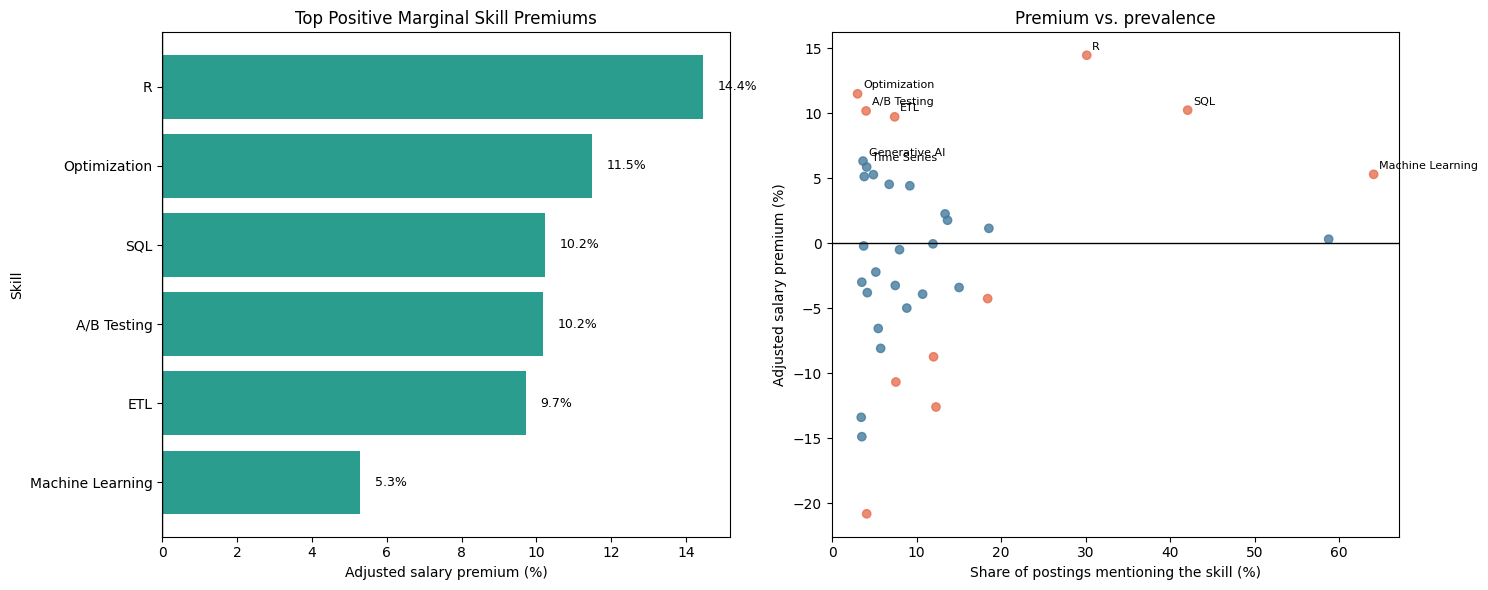

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

plot_df = significant_positive.head(10).copy()
if not plot_df.empty:
    plot_df = plot_df.sort_values("premium_pct")
    axes[0].barh(plot_df["skill"], plot_df["premium_pct"], color="#2a9d8f")
    for idx, row in enumerate(plot_df.itertuples(index=False)):
        axes[0].text(row.premium_pct + 0.4, idx, f"{row.premium_pct:.1f}%", va="center", fontsize=9)
else:
    axes[0].text(0.5, 0.5, "No significant positive skills", ha="center", va="center")

axes[0].set_title("Top Positive Marginal Skill Premiums")
axes[0].set_xlabel("Adjusted salary premium (%)")
axes[0].set_ylabel("Skill")
axes[0].axvline(0, color="black", linewidth=1)

scatter_colors = np.where(results_df["significant_5pct"], "#e76f51", "#457b9d")
axes[1].scatter(results_df["share_pct"], results_df["premium_pct"], c=scatter_colors, alpha=0.8)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Premium vs. prevalence")
axes[1].set_xlabel("Share of postings mentioning the skill (%)")
axes[1].set_ylabel("Adjusted salary premium (%)")

for _, row in results_df.head(8).iterrows():
    axes[1].annotate(row["skill"], (row["share_pct"], row["premium_pct"]), fontsize=8, xytext=(4, 4), textcoords="offset points")

plt.tight_layout()
plt.show()

In [7]:
if significant_positive.empty:
    print("No skill achieved a positive statistically significant marginal premium in this sample.")
else:
    top_ranked = significant_positive.reset_index(drop=True).head(10)
    print("Recommended single-skill learning order by adjusted salary premium:")
    for i, row in enumerate(top_ranked.itertuples(index=False), start=1):
        print(
            f"{i}. {row.skill}: {row.premium_pct:.2f}% premium "
            f"(~${row.approx_salary_delta_usd:,.0f} around the median salary), "
            f"mentioned in {row.support} postings ({row.share_pct:.1f}%)."
        )

    best = top_ranked.iloc[0]
    print()
    print(
        f"Best single-skill bet in this dataset: {best['skill']} "
        f"with an adjusted premium of {best['premium_pct']:.2f}%."
    )

Recommended single-skill learning order by adjusted salary premium:
1. R: 14.45% premium (~$18,203 around the median salary), mentioned in 419 postings (30.1%).
2. Optimization: 11.48% premium (~$14,465 around the median salary), mentioned in 42 postings (3.0%).
3. SQL: 10.22% premium (~$12,883 around the median salary), mentioned in 585 postings (42.1%).
4. A/B Testing: 10.17% premium (~$12,809 around the median salary), mentioned in 56 postings (4.0%).
5. ETL: 9.71% premium (~$12,237 around the median salary), mentioned in 103 postings (7.4%).
6. Machine Learning: 5.29% premium (~$6,662 around the median salary), mentioned in 891 postings (64.1%).

Best single-skill bet in this dataset: R with an adjusted premium of 14.45%.


## Outputs for report

* (1) Variable / Inputs: Dependent variable: Salary (in log scale for better statistical properties). Key independent variable: Presence of each specific skill (binary: yes/no). Control variables: Job remoteness, number of other skills mentioned, data source, job role category, and seniority level.
* (2) Model: OLS regression with HC3 standard errors, run separately for each skill to estimate the marginal premium.
* (3) Finding Statement: We ranked skills by their marginal salary premium (after controlling for job factors like role, seniority, and remoteness). For job seekers, the top 5 skills to learn for the biggest salary boost are: 1. R (14.45% premium), 2. Optimization (11.48%), 3. SQL (10.22%), 4. A/B Testing (10.17%), 5. ETL (9.71%, more related to data engineering jobs but appears in data science roles too). Surprisingly, Machine Learning is not in the top 5 for data science jobs, with only a 5.29% premium, so you might ignore it in favor of these higher-impact skills.
* (4) Limitation or Extension of the Model/Findings: This is based on job posting data and shows associations, not guaranteed personal outcomes. Results are for skills with enough mentions in our dataset. Future work could explore skill combinations or use different data sources. 

## Bonus part: Skills having Negative impact on salary

In [ ]:
# Quite the opposite story on the negative side, with some skills showing a significant negative premium. 
# This could be due to various factors such as market saturation, outdated skills, or skills that are more common in lower-paying roles.

significant_negative = results_df[
    (results_df["premium_pct"] < 0) & (results_df["significant_5pct"])
].sort_values(["premium_pct", "support"], ascending=[True, False]).copy()

print("Skills with the largest statistically significant negative salary premium:")
if significant_negative.empty:
    print("No skills have a negative and statistically significant premium at the 5% level.")
else:
    print(
        significant_negative[
            ["skill", "support", "share_pct", "premium_pct", "approx_salary_delta_usd", "p_value"]
        ].head(20).to_string(index=False)
    )

    bottom_ranked = significant_negative.reset_index(drop=True).head(20)
    print()
    print("Skills to avoid if you are minimizing adjusted salary downside:")
    for i, row in enumerate(bottom_ranked.itertuples(index=False), start=1):
        print(
            f"{i}. {row.skill}: {row.premium_pct:.2f}% premium "
            f"(~${row.approx_salary_delta_usd:,.0f} around the median salary), "
            f"mentioned in {row.support} postings ({row.share_pct:.1f}%)."
        )

    worst = bottom_ranked.iloc[0]
    print()
    print(
        f"Largest negative adjusted skill signal in this dataset: {worst['skill']} "
        f"with an adjusted premium of {worst['premium_pct']:.2f}%."
    )

Skills with the largest statistically significant negative salary premium:
             skill  support  share_pct  premium_pct  approx_salary_delta_usd  p_value
            Docker       57   4.100719   -20.827089            -26242.132176 0.003244
             Azure      171  12.302158   -12.610480            -15889.205084 0.000654
            Pandas      105   7.553957   -10.687621            -13466.402367 0.045231
Data Visualization      167  12.014388    -8.749309            -11024.129817 0.000021
        Statistics      256  18.417266    -4.273072             -5384.070507 0.036556

Skills to avoid if you are minimizing adjusted salary downside:
1. Docker: -20.83% premium (~$-26,242 around the median salary), mentioned in 57 postings (4.1%).
2. Azure: -12.61% premium (~$-15,889 around the median salary), mentioned in 171 postings (12.3%).
3. Pandas: -10.69% premium (~$-13,466 around the median salary), mentioned in 105 postings (7.6%).
4. Data Visualization: -8.75% premium (~$-11,024

In [ ]:
# It looks like some skills have a significant negative premium.

# It's suprizingly to see all of them here, but it mean the such skills are more common 
#       in lower-paying roles or are otherwise associated with starting lower paid positions like Junior. 

# It's a good point for the next experiment actually. 